In [63]:
# Import libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Time series forecasting models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

# Evaluation metric
from sklearn.metrics import mean_squared_error

# Import train_test_split from sklearn
from sklearn.model_selection import train_test_split

# Import XGBoost model
from xgboost import XGBRegressor

In [27]:
# Load dataset
df = pd.read_csv("household_power_consumption.csv")

# Display first 5 rows
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [66]:
df.info() # Display dataset information such as data types and non-null values

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1044506 entries, 2006-12-16 17:24:00 to 2008-12-13 21:38:00
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1044506 non-null  object 
 1   Time                   1044506 non-null  object 
 2   Global_active_power    1044506 non-null  float64
 3   Global_reactive_power  1044506 non-null  object 
 4   Voltage                1044506 non-null  object 
 5   Global_intensity       1044506 non-null  object 
 6   Sub_metering_1         1044506 non-null  object 
 7   Sub_metering_2         1044506 non-null  object 
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(2), object(7)
memory usage: 79.7+ MB


In [67]:
df.describe() # Display Statistical summary

,Global_active_power,Sub_metering_3
count,1.044506e+06,1.044506e+06
mean,1.108202e+00,5.933837e+00
std,1.129546e+00,8.210398e+00
min,7.600000e-02,0.000000e+00
25%,2.880000e-01,0.000000e+00
50%,5.500000e-01,0.000000e+00
75%,1.544000e+00,1.700000e+01
max,1.067000e+01,3.100000e+01


In [68]:
df.isnull().sum() # Check if there are any missing values in the dataset

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


In [69]:
df.dropna(inplace=True) # Drop missing values or null values
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


In [32]:
# Combine Date and Time columns into a single datetime column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# Display data
df.head()

/tmp/ipykernel_508/4205676624.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0,2006-12-16 17:28:00


In [33]:
# Set datetime column as index for time series operations
df.set_index('datetime', inplace=True)

In [34]:
# Convert energy usage column to numeric
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

In [35]:
# Resample data to hourly average power consumption
df_hourly = df['Global_active_power'].resample('h').mean()

In [36]:
# Convert to DataFrame
df_hourly = df_hourly.to_frame(name='energy_usage')

# Display resampled data
df_hourly.head()

,energy_usage
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


In [37]:
# Extract hour of the day
df_hourly['hour'] = df_hourly.index.hour

# Extract weekday number
df_hourly['weekday'] = df_hourly.index.weekday

# Create weekend indicator
df_hourly['is_weekend'] = df_hourly['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# View new features
df_hourly.head()

,energy_usage,hour,weekday,is_weekend
datetime,,,,
2006-12-16 17:00:00,4.222889,17,5,1
2006-12-16 18:00:00,3.632200,18,5,1
2006-12-16 19:00:00,3.400233,19,5,1
2006-12-16 20:00:00,3.268567,20,5,1
2006-12-16 21:00:00,3.056467,21,5,1


In [38]:
# Select features and target
features = ['hour', 'weekday', 'is_weekend']
X = df_hourly[features]          # Input features
y = df_hourly['energy_usage']    # Target variable

# Split the data into training and testing
# shuffle=False is important for time series data to maintain chronological order
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [39]:
# Train ARIMA model using the training portion of the energy usage time series
arima_model = ARIMA(y_train, order=(5,1,0))

# Fit the ARIMA model to learn patterns from historical energy consumption
arima_result = arima_model.fit()

# Forecast future energy usage for the length of the test dataset
arima_forecast = arima_result.forecast(steps=len(y_test))

In [40]:
# Prophet requires a dataframe with columns named 'ds' (date) and 'y' (target)

# Create dataframe using datetime index and target variable
prophet_df = df_hourly.reset_index()[['datetime', 'energy_usage']]

# Rename columns according to Prophet requirements
prophet_df.columns = ['ds', 'y']

# Split Prophet dataset using the same train-test boundary
prophet_train = prophet_df.iloc[:len(y_train)]
prophet_test = prophet_df.iloc[len(y_train):]

In [41]:
# Initialize Prophet model
prophet_model = Prophet()

# Train the model using training data
prophet_model.fit(prophet_train)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [42]:
# Create future dataframe for the length of test data
future = prophet_model.make_future_dataframe(periods=len(prophet_test), freq='h')

# Generate forecast
forecast = prophet_model.predict(future)

# Extract predicted values corresponding to the test period
prophet_forecast = forecast['yhat'].iloc[-len(prophet_test):].values

In [43]:
# Select time-based features used for prediction
features = ['hour', 'weekday', 'is_weekend']

# Define training features and target variable
X_train = df_hourly[features].iloc[:len(y_train)]
y_train = df_hourly['energy_usage'].iloc[:len(y_train)]

# Define testing features and target variable
X_test = df_hourly[features].iloc[len(y_train):]
y_test = df_hourly['energy_usage'].iloc[len(y_train):]

In [56]:
# Check if target variable contains NaN or infinite values
print("NaN in y_train:", y_train.isna().sum())
print("Infinite values:", np.isinf(y_train).sum())

NaN in y_train: 62
Infinite values: 0


In [57]:
# Remove rows where target has NaN or infinite values
valid_index = y_train.replace([np.inf, -np.inf], np.nan).dropna().index

# Keep only valid rows in features and target
X_train = X_train.loc[valid_index]
y_train = y_train.loc[valid_index]

In [58]:
# Initialize XGBoost regressor
xgb_model = XGBRegressor(objective='reg:squarederror')

# Train the model using cleaned training data
xgb_model.fit(X_train, y_train)

# Predict energy consumption on test data
xgb_forecast = xgb_model.predict(X_test)

In [62]:
# Calculate RMSE for each model
arima_rmse = np.sqrt(mean_squared_error(y_test, arima_forecast))
prophet_rmse = np.sqrt(mean_squared_error(prophet_test['y'], prophet_forecast))
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_forecast))

# Print model comparison
print("ARIMA RMSE:", arima_rmse)
print("Prophet RMSE:", prophet_rmse)
print("XGBoost RMSE:", xgb_rmse)

ARIMA RMSE: 1.1195223563756342
Prophet RMSE: 0.9417508991557251
XGBoost RMSE: 0.8229934738754124


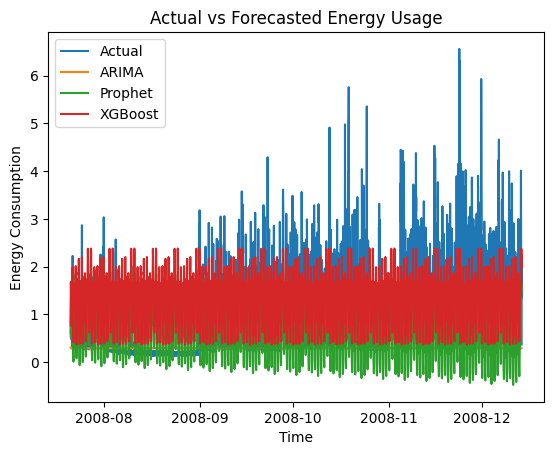

In [65]:
# Plot actual energy usage
plt.plot(y_test.index, y_test, label='Actual')

# Plot predictions from models
plt.plot(y_test.index, arima_forecast, label='ARIMA')
plt.plot(y_test.index, prophet_forecast, label='Prophet')
plt.plot(y_test.index, xgb_forecast, label='XGBoost')
plt.xlabel("Time")
plt.ylabel("Energy Consumption")
plt.title("Actual vs Forecasted Energy Usage")
plt.legend()
plt.show()